In [19]:
import numpy as np
import matplotlib.pyplot as plt
import gzip

# Data Pre-processing

In [20]:
with gzip.open('./data/MNIST/raw/t10k-images-idx3-ubyte.gz') as file:
    print(np.frombuffer(file.read(64)).shape)

(8,)


In [21]:
def read_idx_images(filepath):
    with gzip.open(filepath, 'rb') as f:

        header = np.frombuffer(f.read(16), dtype='>i4')  
        magic, num_images, rows, cols = header


        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(num_images, rows, cols)
    return images

def read_idx_labels(filepath):
    with gzip.open(filepath, 'rb') as f:

        header = np.frombuffer(f.read(8), dtype='>i4')
        magic, num_labels = header

        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [22]:
train_images = read_idx_images("data/MNIST/raw/train-images-idx3-ubyte.gz")
train_labels = read_idx_labels("data/MNIST/raw/train-labels-idx1-ubyte.gz")

test_images = read_idx_images("data/MNIST/raw/t10k-images-idx3-ubyte.gz")
test_labels = read_idx_labels("data/MNIST/raw/t10k-labels-idx1-ubyte.gz")

In [23]:
print(train_images.shape)
print(train_labels.shape)

print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [24]:
train_images = train_images / np.max(train_images)
test_images = test_images / np.max(test_images)

In [25]:
mean = np.mean(train_images)
std = np.std(train_images)

In [26]:
print(mean)
print(std)

0.1306604762738429
0.30810780385646264


In [27]:
train_data = (train_images - mean) / std
test_data = (test_images - mean) / std

# Model declaration

In [28]:
def ReLU(x):
    c = x.copy()
    c[c < 0] = 0
    return c

In [47]:
class MNIST:
    def __init__(self):
        self.W1 = np.random.rand(64, 784) * 0.01
        self.b1 = np.random.rand(1, 64) * 0.01
        self.W2 = np.random.rand(10, 64) * 0.01
        self.b2 = np.random.rand(1, 10) * 0.01
        self.loss = 0.0

    def forward(self, x, p):

        x = x.reshape(64, 784)
        z1 = x @ self.W1.T + self.b1 # 64 x 784 @ 784 x 64 + 1 x 64
        a1 = ReLU(z1) # 64 x 64
        z2 = a1 @ self.W2.T + self.b2 # 64 x 64 @ 64 x 10 + 1 x 10
        z2 = z2 - np.max(z2, axis=1, keepdims=True)
        q = np.exp(z2) / np.sum(np.exp(z2), axis=1, keepdims=True)


        self.loss = -np.sum(p * np.log(q), axis=0, keepdims=True, dtype=np.float128)

        dz = z1.copy()
        dz[dz < 0] = 0
        dz[dz > 0] = 1

        delta = ((q - p) @ self.W2 * dz) # 64 x 10 @ 10 x 64 * 64 x 64 = 64 x 64
        dW1 = (delta.T @ x) / 64 # 64 x 64 @ 64 x 784 = 64 x 784
        db1 = (np.sum(delta, axis=0, keepdims=True)) / 64 # 1 x 64

        dW2 = ((q - p).T @ a1) / 64 # 10 x 64 @ 64 x 64 = 10 x 64
        db2 = (np.sum(q - p, axis=0, keepdims=True)) / 64 # 1 x 10

        self.W1 = self.W1 - 0.01 * dW1 
        self.b1 = self.b1 - 0.01 * db1 
        self.W2 = self.W2 - 0.01 * dW2 
        self.b2 = self.b2 - 0.01 * db2

    def predict(self, data):
        z1 = data @ self.W1.T + self.b1
        a1 = ReLU(z1)
        z2 = a1 @ self.W2.T + self.b2

        z2 = z2 - np.max(z2)

        return np.exp(z2) / np.sum(np.exp(z2), axis=1, keepdims=True)


In [38]:
def train(model, train_data, label):
    batch_idx = np.random.permutation(60000)
    start = 0
    loss = 0.0
    for end in range(64, 60000, 64):
        nb_classes = 10
        p = np.eye(nb_classes, dtype=np.float64)[label[batch_idx[start:end]]]
        model.forward(train_data[batch_idx[start: end]], p)
        start = end
        loss += model.loss
    loss = loss / 60000

    return model, np.average(loss)

In [31]:
batch_idx = np.random.permutation(60000)
nb_classes = 10
p = np.eye(nb_classes)[train_labels[batch_idx[0:5]]]
print(p)

train_labels[batch_idx[0:5]]

[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


array([2, 1, 9, 8, 3], dtype=uint8)

In [112]:
np.eye(10)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [48]:
model = MNIST()

In [49]:
num_epoch = 5

In [50]:
for epoch in range(num_epoch):
    model, loss = train(model, train_data, train_labels)
    print(loss)

0.13778132367897508894
0.039542035199017067053
0.031256945173169793584
0.02778576606190736644
0.025397511508167739874


In [104]:
test_idx = 234

In [105]:
prediction = model.predict(test_data[test_idx].reshape(1, 784))

In [106]:
prediction.shape

(1, 10)

In [110]:
np.where(np.isclose(prediction, np.max(prediction)))

(array([0]), array([7]))

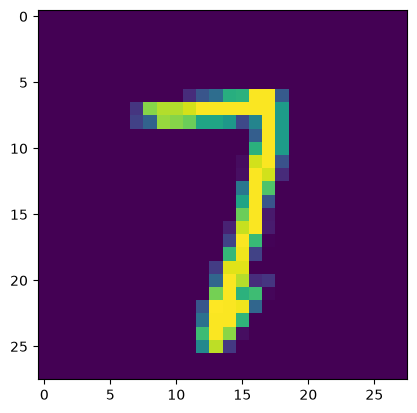

In [111]:
plt.imshow(test_data[test_idx])